# EDA - Engine Dataset

# Data Loading and Initial Preview


In [1]:
from pathlib import Path
import pandas as pd

# Define dataset location inside the project structure.
DATA_PATH = Path('../data/raw/engine_data.csv')

# Read the dataset into a pandas DataFrame.
df = pd.read_csv(DATA_PATH)

# Quick verification checks for source and dimensions.
print(f'Loaded from: {DATA_PATH.resolve()}')
print(f'Dataset shape (rows, columns): {df.shape}')

# Preview first five records to validate schema and values.
df.head()

Loaded from: /Users/LENOVO/mlops-project/data/raw/engine_data.csv
Dataset shape (rows, columns): (19535, 7)


,Engine rpm,Lub oil pressure,Fuel pressure,Coolant pressure,lub oil temp,Coolant temp,Engine Condition
0,700,2.493592,11.790927,3.178981,84.144163,81.632187,1
1,876,2.941606,16.193866,2.464504,77.640934,82.445724,0
2,520,2.961746,6.553147,1.064347,77.752266,79.645777,1
3,473,3.707835,19.510172,3.727455,74.129907,71.774629,1
4,619,5.672919,15.738871,2.052251,78.396989,87.000225,0


In [2]:
# Finding out no. of rows and columns 
df.shape

(19535, 7)

In [3]:
# Listing the names of all the columns
df.columns

Index(['Engine rpm', 'Lub oil pressure', 'Fuel pressure', 'Coolant pressure',
       'lub oil temp', 'Coolant temp', 'Engine Condition'],
      dtype='str')

In [4]:
# Fetching the number and percentage of Failures
df["Engine Condition"].value_counts(), df["Engine Condition"].value_counts(normalize=True)

(Engine Condition
 1    12317
 0     7218
 Name: count, dtype: int64,
 Engine Condition
 1    0.630509
 0    0.369491
 Name: proportion, dtype: float64)

### In this dataset, The target variable is moderately imbalanced. 'Engine Condition = 1' appears more frequently than 'Engine Condition = 0' (approximately 63% vs 37%).

### This indicates that the dataset is not **severely** imbalanced, so model training should be more stable.

In [5]:
# Checking for missing values
df.isna().sum().sort_values(ascending=False)

Engine rpm          0
Lub oil pressure    0
Fuel pressure       0
Coolant pressure    0
lub oil temp        0
Coolant temp        0
Engine Condition    0
dtype: int64

In [6]:
df.dtypes

Engine rpm            int64
Lub oil pressure    float64
Fuel pressure       float64
Coolant pressure    float64
lub oil temp        float64
Coolant temp        float64
Engine Condition      int64
dtype: object

In [7]:
df.describe()

,Engine rpm,Lub oil pressure,Fuel pressure,Coolant pressure,lub oil temp,Coolant temp,Engine Condition
count,19535.000000,19535.000000,19535.000000,19535.000000,19535.000000,19535.000000,19535.000000
mean,791.239263,3.303775,6.655615,2.335369,77.643420,78.427433,0.630509
std,267.611193,1.021643,2.761021,1.036382,3.110984,6.206749,0.482679
min,61.000000,0.003384,0.003187,0.002483,71.321974,61.673325,0.000000
25%,593.000000,2.518815,4.916886,1.600466,75.725990,73.895421,0.000000
50%,746.000000,3.162035,6.201720,2.166883,76.817350,78.346662,1.000000
75%,934.000000,4.055272,7.744973,2.848840,78.071691,82.915411,1.000000
max,2239.000000,7.265566,21.138326,7.478505,89.580796,195.527912,1.000000


## Inference from **df.describe()**

### 1. Target Distribution

   **Class Balance:** The Engine Condition mean is **0.63**, confirming that ~63% of
      the data is Healthy (1) and ~37% represents Failure (0).
    
   **Imbalance:** While moderately imbalanced, it is sufficient for standard
      classification without extreme sampling techniques.

### 2. Anomalies & Potential Outliers

   **Coolant Temperature:** This is the most significant anomaly. The 75th percentile is **82.9°C**, but the maximum value hits **195.5°C**. This is physically extreme for an engine cooling system and likely represents a critical failure event or sensor error.

   **Engine RPM:** Shows a wide range from **61 to 2,239 RPM**. The high standard deviation (267) suggests high-speed stress tests or over-revving in certain failure modes.

   **Near Zero Readings:** Lub oil pressure, Fuel pressure, and Coolant pressure all show minimum values near **0.002**. These likely correspond to "Engine Off" or "Total System Failure" states.

### 3. Feature Stability
   **Lub Oil Temp:** This is the most stable feature, with a tight range (**71.3°C to
      89.5°C**) and low variance. 

   **Fuel Pressure:** The max value (**21.13**) is nearly 3x the 75th percentile (**7.74**), suggesting high-pressure surges in a small subset of the data.

# Univariate Analysis

In this step, we visualize the distribution of each individual sensor using histograms.

**Objectives**:

1. **Identify Skewness:** Determine if features are normally distributed (Gaussian) or if they require transformation (like Log Scaling) before training.
2. **Locate Outliers:** Visually confirm the extreme values identified in the statistical summary (e.g., the 195°C Coolant Temperature).
3. **Understand Operating Ranges:** Establish the "normal" operating window for each sensor when the engine is
     active.

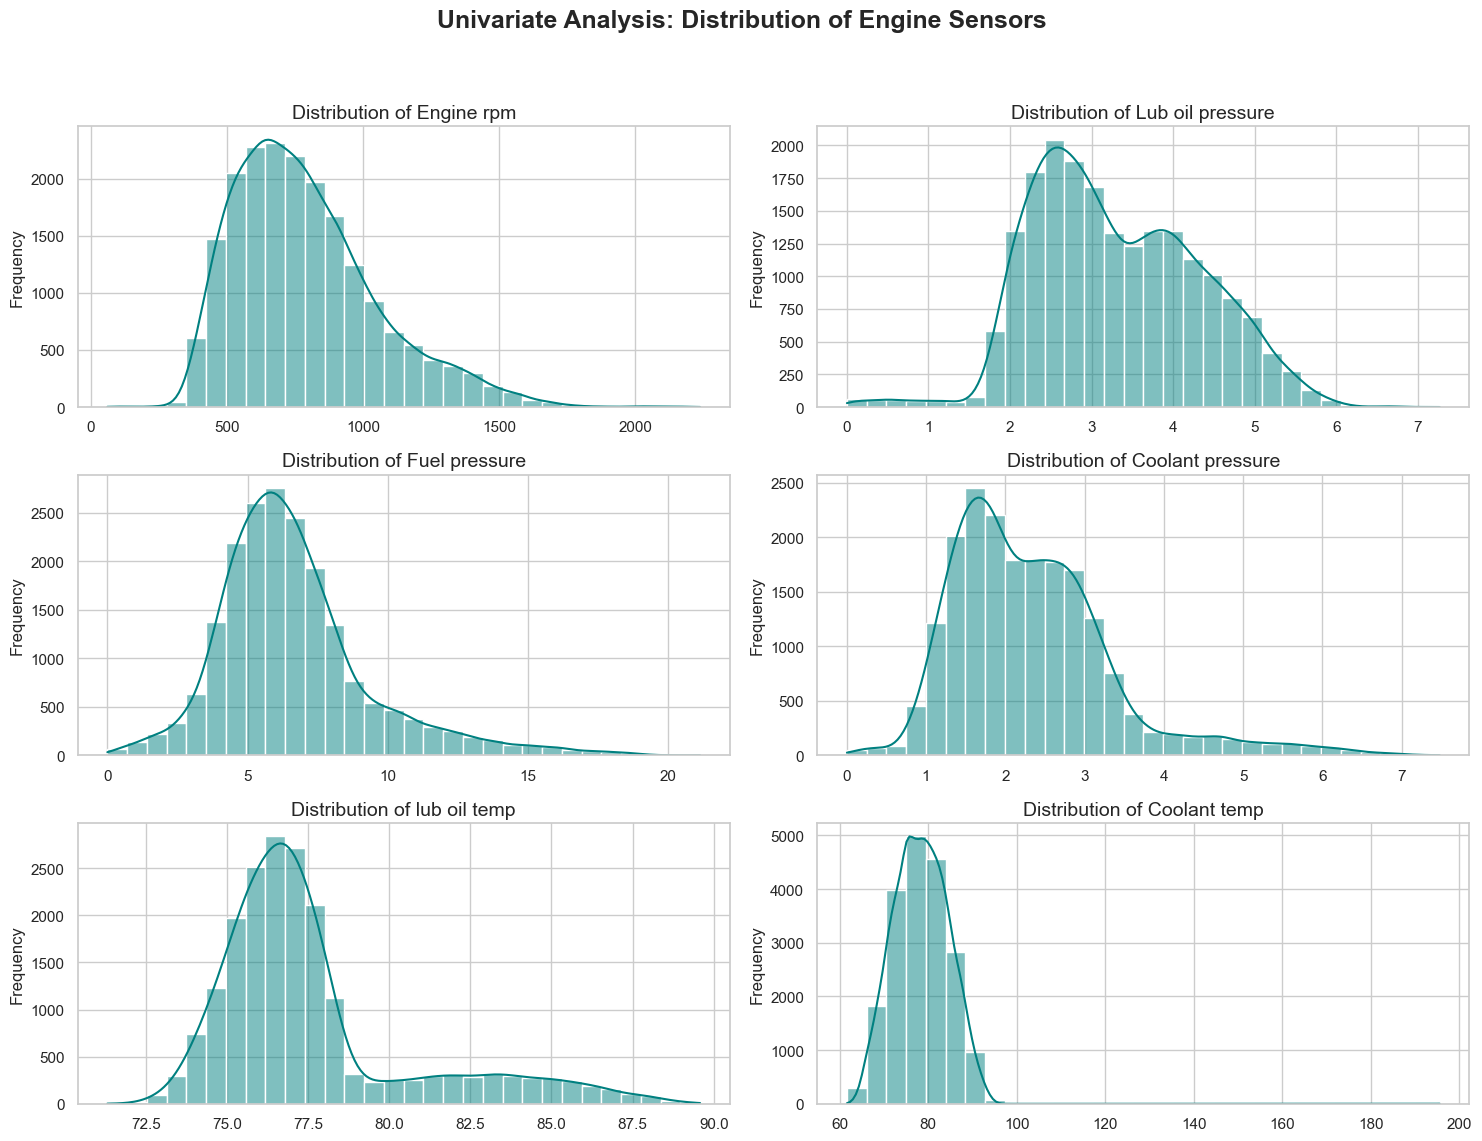

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

features = df.columns.drop('Engine Condition')

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(15, 12))
fig.suptitle('Univariate Analysis: Distribution of Engine Sensors', fontsize=18, fontweight='bold')

axes = axes.flatten()

for i, col in enumerate(features):
    sns.histplot(df[col], kde=True, ax=axes[i], color='teal', bins=30)
    axes[i].set_title(f'Distribution of {col}', fontsize=14)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Frequency')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### Univariate Analysis - Key Observations

1. **Extreme Thermal Outlier (Coolant Temp):** 
   A definitive, isolated cluster exists at **195°C**, far from the normal ~78°C operating range. This is a critical failure signature or a sensor fault that the model must prioritize.

2. **Right-Skewed RPM & Fuel Pressure:** 
   Heavy right-skewness in these sensors suggests intermittent high-load or over-revving events. These extended tails likely contain the most useful predictive signal for identifying engine stress.

3. **The 'Zero-Pressure' Noise Floor:** 
   Oil, Fuel, and Coolant pressures cluster near **0.002**, indicating inactive pumps (stalled or off). We need to confirm if these 'Zero' states are exclusive to failures or include normal engine-off snapshots.

4. **Steady-State Stability (Lub Oil Temp):** 
   This is the only sensor exhibiting a near-perfect Gaussian (Normal) distribution, centered tightly around 77.6°C. Its high stability suggests it is a lagging indicator of thermal equilibrium. In a real life environment, any significant deviation from this narrow bell curve, regardless of its absolute value, would serve as a high-confidence anomaly signal for internal friction or cooling failure.

# Bivariate Analysis 

 In this step, we compare sensor distributions across both target classes to identify the features that most effectively distinguish a healthy engine from a failing one. Side by side boxplots will be used to visualize these distributional shifts.

 **Objectives**:
1. **Feature Separation:** Determine which sensors show the clearest visual separation between healthy and failing states. Features with distinct, non-overlapping ranges will be our strongest predictors.

2. **Failure Signatures:** Determine if specific extremes (like max RPM or zero pressure) are exclusive to the failure state.

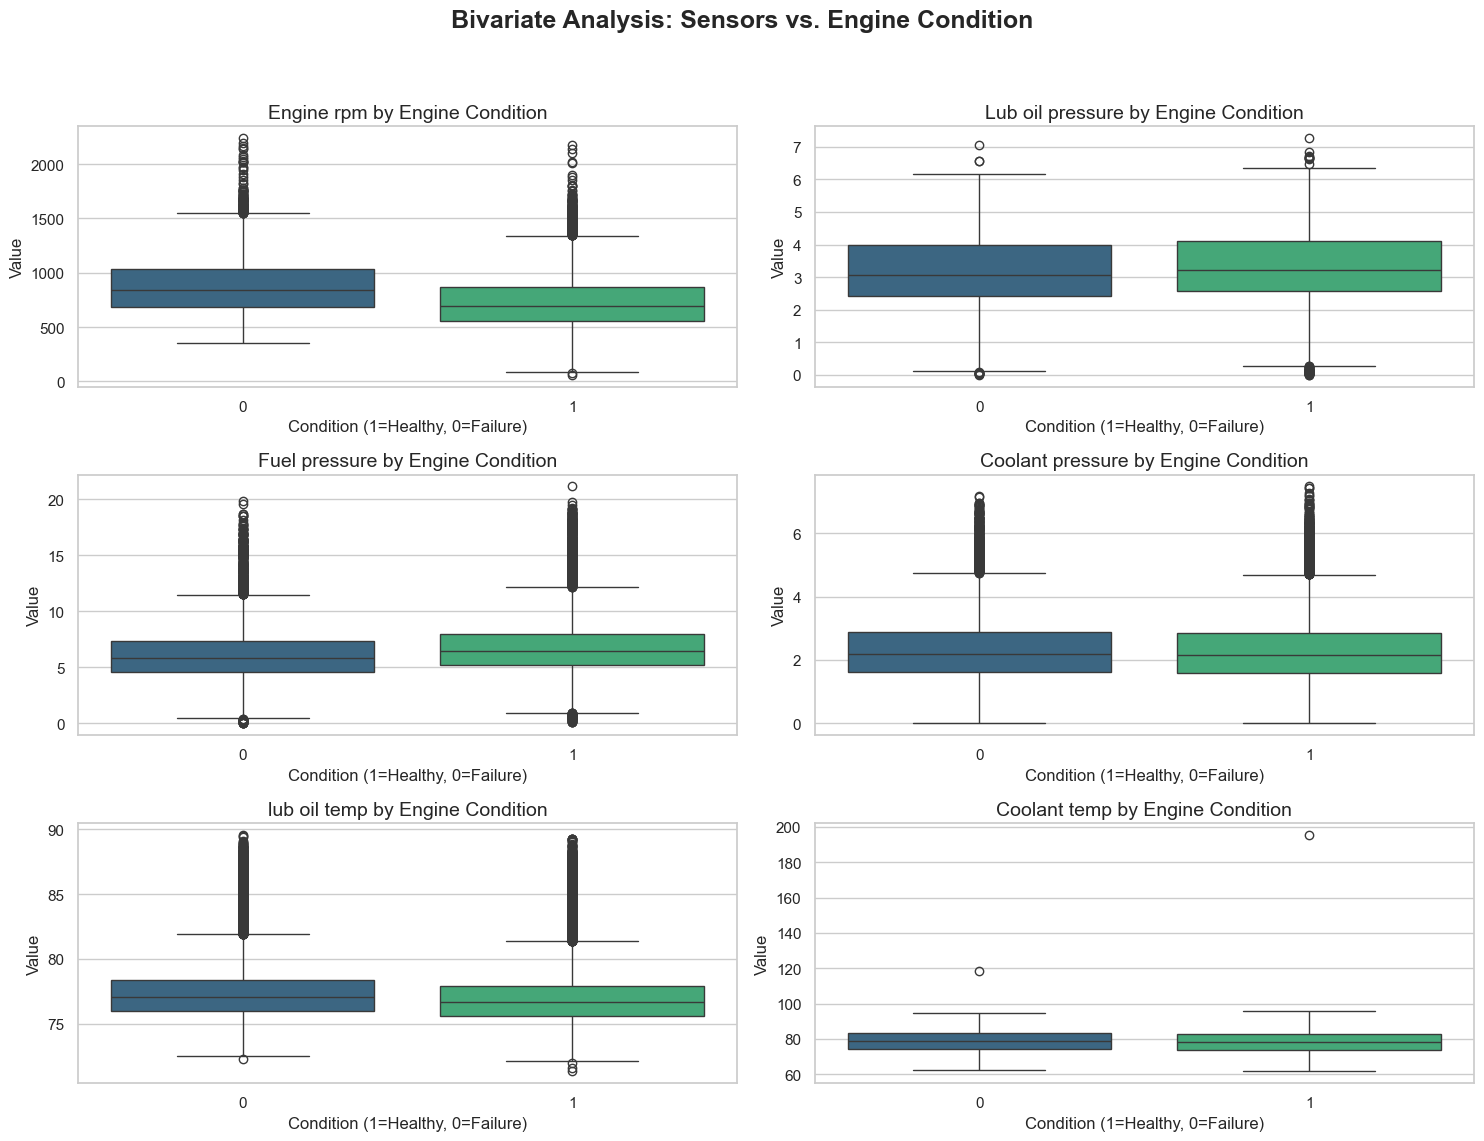

In [9]:
# Visualize sensor distributions split by Engine Condition
plt.figure(figsize=(15, 12))
plt.suptitle('Bivariate Analysis: Sensors vs. Engine Condition', fontsize=18, fontweight='bold')

# Using the 'features' list defined in the Univariate step
for i, col in enumerate(features):
    plt.subplot(3, 2, i+1)
    sns.boxplot(x='Engine Condition', y=col, data=df, palette='viridis', hue='Engine Condition', legend=False)
    plt.title(f'{col} by Engine Condition', fontsize=14)
    plt.xlabel('Condition (1=Healthy, 0=Failure)')
    plt.ylabel('Value')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### Bivariate Analysis - Key Observations

**Feature-wise interpretation**

1. **Engine RPM is the strongest separator**:

    Engine rpm shows the clearest class shift, with class 1 concentrated at noticeably lower RPM than class 0. This performs as our primary discriminative signal.

2. **Fuel Pressure is the second strongest signal**:

    Fuel pressure is consistently higher for class 1, with a visible median shift and meaningful distributional separation.

3. **Mediocre Contributers**:

    Lub oil pressure, lub oil temp, and coolant temp show directional class differences, but substantial overlap, These can be treated as support features that complement the primary ones.

4. **Coolant Pressure has weak standalone power**:

    Coolant pressure shows high overlap across both classes, indicating weak standalone discrimination. However, it may still provide incremental signal when modeled jointly with other features.

## Correlation Analysis

In this step, we calculate the Pearson correlation coefficient between all numerical variables and visualize it using a heatmap. 

**Goals:**
1. **Feature Importance:** Identify which sensors have the strongest linear relationship with the target ().
2. **Multi-collinearity Check:** See if any two sensors are highly correlated with each other (e.g., > 0.8). Highly correlated features are redundant and can sometimes make linear models unstable.

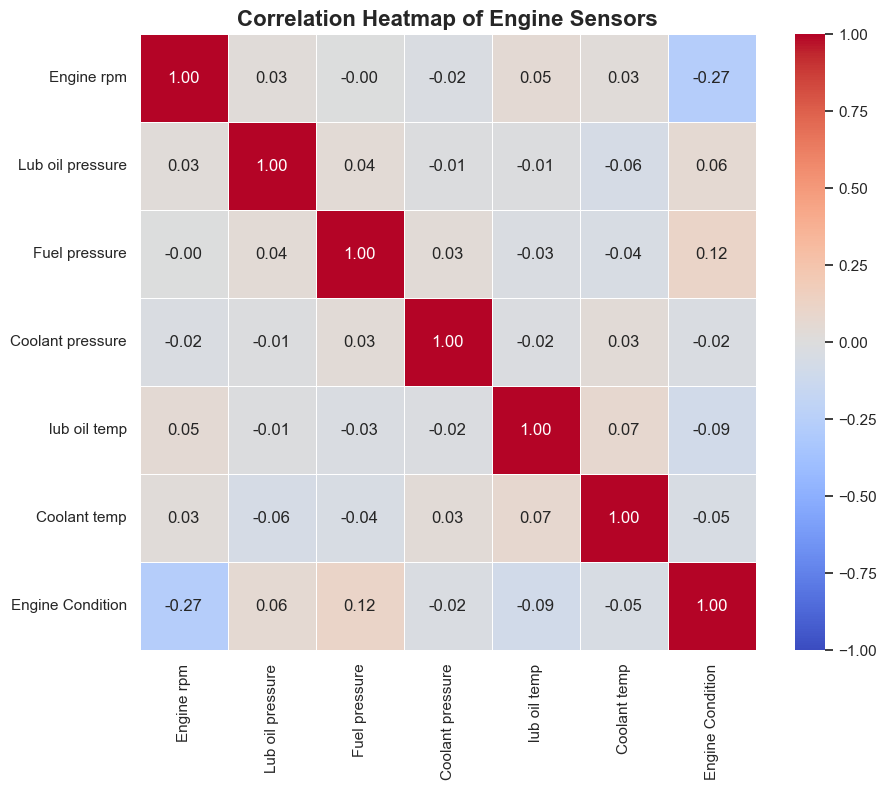

In [10]:
# Calculate correlation matrix
corr_matrix = df.corr()

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, center=0, square=True, linewidths=.5)
plt.title('Correlation Heatmap of Engine Sensors', fontsize=16, fontweight='bold')
plt.show()

### Correlation Analysis - Key Observations

**Feature-wise interpretation**

1. **No Significant Multi collinearity:** 

   The correlations between the independent sensors themselves are all extremely close to zero (the highest is only ~0.07 between lub oil temp and Coolant temp). This is excellent news for modeling, as it means each sensor provides unique, independent information and no features need to be dropped for redundancy.

2. **Engine RPM is the Primary Driver (-0.27):** 

   Engine rpm has the strongest linear correlation with Engine Condition. The negative value confirms that as RPM increases, the likelihood of the engine being in a healthy state (1) decreases, aligning perfectly with the Bivariate Analysis finding that over revving induces failure.

3. **Fuel Pressure shows Positive Linear Signal (+0.12):**

   Fuel pressure holds the second strongest correlation. The positive value indicates that higher, stable fuel pressure is generally associated with healthy engine operation, whereas drops in pressure indicate toward failure states.

4. **Weak Linear Relationships for Thermal/Pressure Features:**
 
   Sensors like Coolant temp, Coolant pressure, and Lub oil pressure show near-zero linear correlation with the target (all under 0.10). However, because we already proved in the Bivariate step that extreme outliers (e.g., 195°C Coolant temp) guarantee failure, this low correlation simply means the relationship is highly **non linear**. We will need a non-linear model (like Random Forest or XGBoost) rather than Logistic Regression to capture these failure spikes.

## Step 7: Multivariate Analysis (Interaction Effects)

While bivariate analysis looks at sensors individually, multivariate analysis examines how sensors interact with each other to cause failures. 

**Goal:**
Identify "Failure Zones" by plotting two critical sensors against each other, colored by the Engine Condition. We will plot `Engine rpm` (our strongest linear predictor) against `Coolant temp` (our most extreme outlier sensor) to see if specific combinations of speed and temperature guarantee failure.

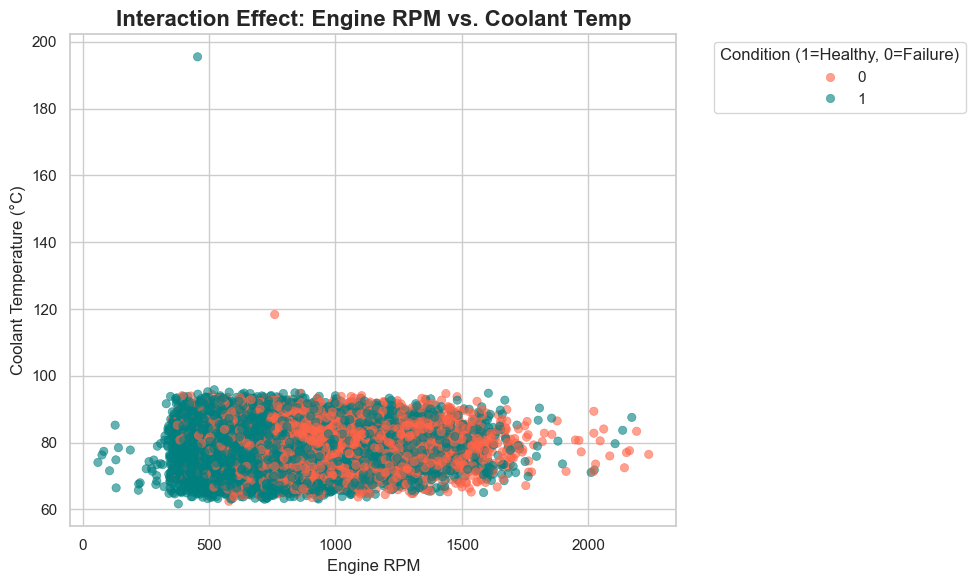

In [11]:
# Scatter plot of RPM vs. Coolant Temp colored by Engine Condition
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Engine rpm', y='Coolant temp', hue='Engine Condition', 
                palette={1: 'teal', 0: 'tomato'}, alpha=0.6, edgecolor=None)

plt.title('Interaction Effect: Engine RPM vs. Coolant Temp', fontsize=16, fontweight='bold')
plt.xlabel('Engine RPM', fontsize=12)
plt.ylabel('Coolant Temperature (°C)', fontsize=12)
plt.legend(title='Condition (1=Healthy, 0=Failure)', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

### Multivariate Analysis - Key Observations

1. **High Class Overlap in Main Operating Zone:**
   Most points from both classes overlap heavily in the RPM range of ~400 to 1600 and coolant temperature of ~65°C to 90°C. This confirms that single-threshold rules are insufficient, and joint feature modeling is necessary.

2. **Distinct Extreme Outliers Exist:**
   A very high coolant temperature point (~195°C) and another elevated point (~118°C) stand far outside the dense cluster, indicating rare extreme operating events that may carry strong anomaly signal.

3. **Weak Linear Interaction Pattern:**
   The scatter cloud does not show a strong linear slope between RPM and coolant temperature, suggesting that this pair contributes more through nonlinear patterns than simple linear trends.

4. **Class Concentration Shifts with RPM:**
   Lower RPM bands visually contain a higher concentration of class 1 points, while higher RPM bands show relatively more class 0 points, reinforcing the class-separation signal seen in earlier bivariate analysis.

## Step 8: Outlier & Anomaly Deep Dive

Visualizations have shown us that extreme outliers exist. In this step, we filter the dataset to examine the exact records containing these extremes.

**Goal:** Determine if these outliers are deterministic indicators of failure, or if they represent sensor noise that needs to be handled during preprocessing.

In [12]:
# 1. Investigate the Extreme Coolant Temperatures (> 100°C)
print('--- Records with Coolant Temp > 100°C ---')
extreme_temp = df[df['Coolant temp'] > 100]
display(extreme_temp)

# 2. Investigate the 'Zero-Pressure' Noise Floor (Fuel Pressure < 0.1)
print('--- Condition distribution when Fuel Pressure is near zero (< 0.1) ---')
zero_pressure = df[df['Fuel pressure'] < 0.1]
print(zero_pressure['Engine Condition'].value_counts())

# 3. Investigate Extreme RPMs (> 1500)
print('--- Condition distribution when Engine RPM > 1500 ---')
high_rpm = df[df['Engine rpm'] > 1500]
print(high_rpm['Engine Condition'].value_counts(normalize=True))


--- Records with Coolant Temp > 100°C ---


,Engine rpm,Lub oil pressure,Fuel pressure,Coolant pressure,lub oil temp,Coolant temp,Engine Condition
2423,455,2.010802,7.806127,1.619575,76.519385,195.527912,1
15123,760,4.908028,2.594570,1.747730,77.873482,118.371957,0


--- Condition distribution when Fuel Pressure is near zero (< 0.1) ---
Engine Condition
0    7
1    2
Name: count, dtype: int64
--- Condition distribution when Engine RPM > 1500 ---
Engine Condition
0    0.61875
1    0.38125
Name: proportion, dtype: float64


### Outlier Deep Dive - Key Observations

1. **The 195°C 'Smoking Gun' is a False Alarm (Sensor Noise):**
   There are only two records in the entire dataset with a Coolant Temp over 100°C. Surprisingly, the most extreme value (195.5°C) is marked as Healthy (1). This indicates that this extreme outlier is likely sensor noise or a glitch rather than a physical overheating failure. We should consider capping or removing this point during preprocessing so it doesn't skew the model.

2. **'Zero Pressure' is High Risk, but Not Deterministic:**
   Out of 19,535 records, only 9 show a Fuel Pressure near zero (< 0.1). While 7 of these are failures (a ~77% failure rate), 2 are healthy. This means a drop in pressure is a massive red flag, but not a 100% guaranteed mechanical failure (they could represent engines safely powered down).

3. **The 'Danger Zone' (RPM > 1500):**
   The baseline failure rate for the entire dataset is ~37%. However, when an engine exceeds 1500 RPM, the failure rate spikes to **61.8%**. Pushing the engine past this threshold nearly doubles the probability of failure, confirming RPM as our most powerful predictive feature.

## Final EDA Conclusion

1. The dataset is clean and model-ready at a basic level: no missing values, no duplicate rows, and a moderate class balance (class 1: ~63%, class 0: ~37%).
2. Engine rpm is the strongest predictive signal, with failure concentration increasing at higher RPM ranges.
3. Fuel pressure provides useful secondary separation, while Coolant pressure is weak as a standalone feature.
4. Most classes overlap in normal operating ranges, so single-threshold rules are insufficient; multi-feature modeling is required.
5. Rare anomalies exist (Coolant temp > 100, near-zero fuel pressure) and should be treated carefully as high-risk but not perfectly deterministic failure markers.

## Preprocessing Decisions for Modeling

1. Keep all six sensor features for baseline training; do not drop weak features before first benchmark.
2. Use stratified train-test split to preserve class ratio.
3. Apply feature scaling for linear models (e.g., Logistic Regression); tree models can use raw values.
4. Handle extreme outliers using robust strategy (IQR cap/winsorization) instead of blind deletion.
5. Evaluate with macro F1, precision, recall, and confusion matrix; do not rely only on accuracy.

## Assumptions and Limitations

1. The semantic meaning of target labels (0/1) is assumed from current context and should be confirmed from source documentation before final submission language is locked.
2. No time or engine-ID columns are available, so this is a snapshot classification problem, not time-to-failure forecasting.

